In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [2]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by all Pathologist

In [49]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator3', 'evaluator4', 'evaluator5']
correct_answers_eval_data = {}
wrong_answers_eval_data = {}
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathopen_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data[evaluator_id] = eval_data

    wrong_answer_eval_data_path = f"output/{evaluator_id}/pathopen_wrong_answer_eval_data.pkl"
    eval_data = pd.read_pickle(wrong_answer_eval_data_path)
    wrong_answers_eval_data[evaluator_id] = eval_data

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Correct Answers

Open-Ended Knowledge Interpretation

In [32]:
correct_answers_open_ended_know_inter = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator5')])

correct_answers_open_ended_know_inter['Level 2'] = round((correct_answers_open_ended_know_inter['Level 2']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 1'] = round((correct_answers_open_ended_know_inter['Level 1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 0'] = round((correct_answers_open_ended_know_inter['Level 0']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level -1'] = round((correct_answers_open_ended_know_inter['Level -1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter = correct_answers_open_ended_know_inter.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_know_inter

,2,1,0,-1
Evaluator1,90.22,8.70,1.09,0.00
Evaluator2,96.67,3.33,0.00,0.00
Evaluator3,98.89,1.11,0.00,0.00
Evaluator4,98.91,1.09,0.00,0.00
Evaluator5,90.22,3.26,2.17,4.35


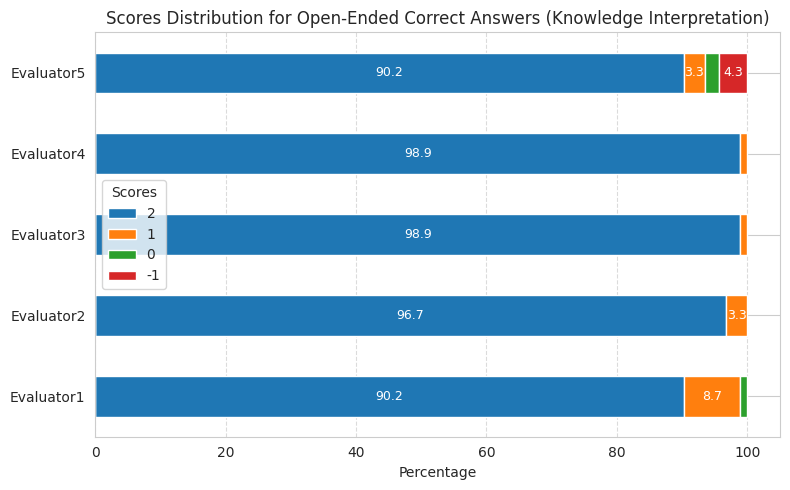

In [41]:
ax = correct_answers_open_ended_know_inter.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for Open-Ended Correct Answers (Knowledge Interpretation)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers_know_inter.png')
plt.show()

Open-Ended Visual Grounding

In [25]:
correct_answers_open_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_open_ended_vis_grounding['Level 2'] = round((correct_answers_open_ended_vis_grounding['Level 2']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 1'] = round((correct_answers_open_ended_vis_grounding['Level 1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 0'] = round((correct_answers_open_ended_vis_grounding['Level 0']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level -1'] = round((correct_answers_open_ended_vis_grounding['Level -1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding = correct_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_vis_grounding

,2,1,0,-1
Evaluator1,89.13,9.78,1.09,0.00
Evaluator2,97.78,2.22,0.00,0.00
Evaluator3,97.78,2.22,0.00,0.00
Evaluator4,96.74,2.17,1.09,0.00
Evaluator5,85.87,6.52,3.26,4.35


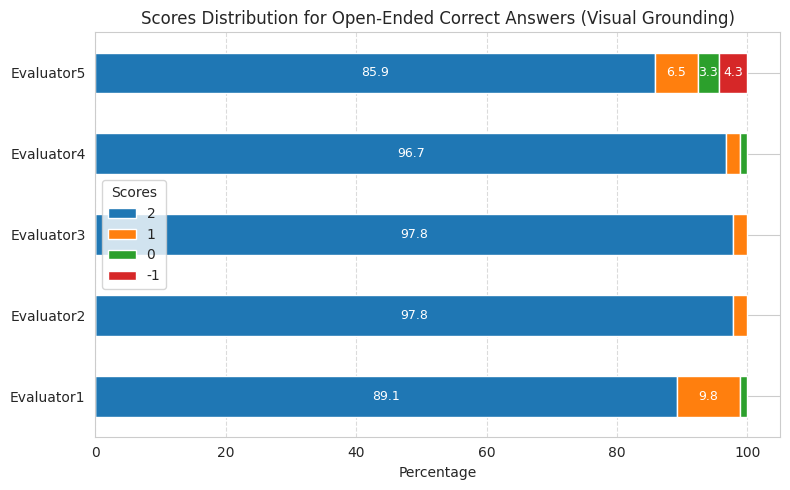

In [42]:
ax = correct_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for Open-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers_vis_grounding.png')
plt.show()

MCQ Knowledge Interpretation

In [43]:
correct_answers_mcq_know_inter = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator5')])

correct_answers_mcq_know_inter['Level 2'] = round((correct_answers_mcq_know_inter['Level 2']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level 1'] = round((correct_answers_mcq_know_inter['Level 1']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level 0'] = round((correct_answers_mcq_know_inter['Level 0']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level -1'] = round((correct_answers_mcq_know_inter['Level -1']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter = correct_answers_mcq_know_inter.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                        'Level 1': '1',
                                                                                                        'Level 0': '0',
                                                                                                        'Level -1': '-1'})

correct_answers_mcq_know_inter

,2,1,0,-1
Evaluator1,93.48,2.17,4.35,0.00
Evaluator2,100.00,0.00,0.00,0.00
Evaluator3,97.83,0.00,2.17,0.00
Evaluator4,100.00,0.00,0.00,0.00
Evaluator5,89.13,4.35,4.35,2.17


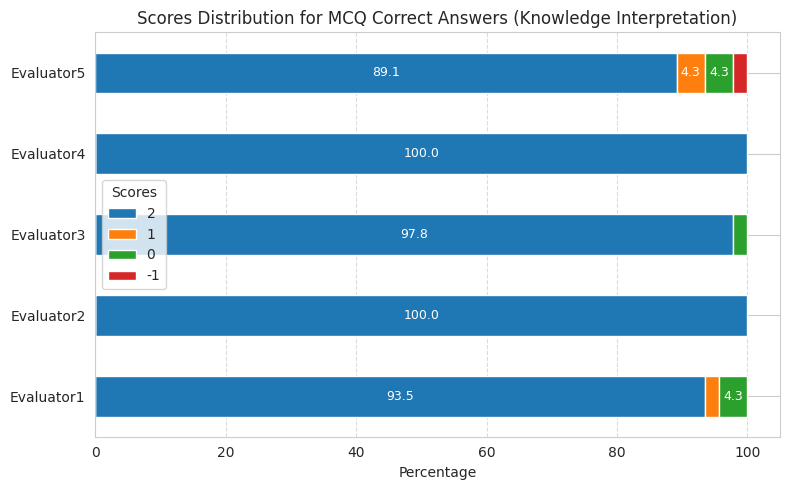

In [45]:
ax = correct_answers_mcq_know_inter.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for MCQ Correct Answers (Knowledge Interpretation)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers_know_inter.png')
plt.show()

MCQ Visual Grounding

In [46]:
correct_answers_mcq_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['MCQ', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['MCQ', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['MCQ', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['MCQ', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['MCQ', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_mcq_vis_grounding['Level 2'] = round((correct_answers_mcq_vis_grounding['Level 2']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level 1'] = round((correct_answers_mcq_vis_grounding['Level 1']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level 0'] = round((correct_answers_mcq_vis_grounding['Level 0']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level -1'] = round((correct_answers_mcq_vis_grounding['Level -1']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding = correct_answers_mcq_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

correct_answers_mcq_vis_grounding

,2,1,0,-1
Evaluator1,93.48,2.17,4.35,0.00
Evaluator2,91.30,6.52,2.17,0.00
Evaluator3,95.65,2.17,2.17,0.00
Evaluator4,100.00,0.00,0.00,0.00
Evaluator5,80.43,13.04,4.35,2.17


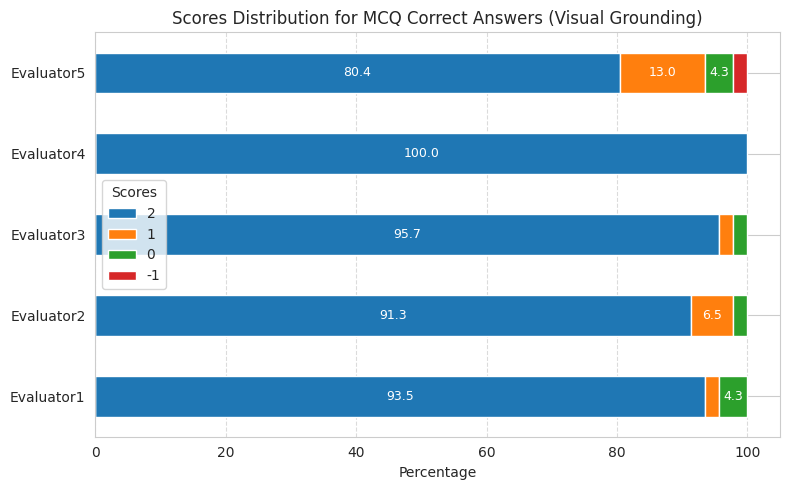

In [47]:
ax = correct_answers_mcq_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for MCQ Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers_vis_grounding.png')
plt.show()

Close-Ended Visual Grounding

In [13]:
correct_answers_close_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_close_ended_vis_grounding['Level 2'] = round((correct_answers_close_ended_vis_grounding['Level 2']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 1'] = round((correct_answers_close_ended_vis_grounding['Level 1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 0'] = round((correct_answers_close_ended_vis_grounding['Level 0']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level -1'] = round((correct_answers_close_ended_vis_grounding['Level -1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding = correct_answers_close_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

correct_answers_close_ended_vis_grounding

,2,1,0,-1
Evaluator1,100.00,0.00,0.00,0.0
Evaluator2,93.48,4.35,2.17,0.0
Evaluator3,97.83,2.17,0.00,0.0
Evaluator4,95.65,2.17,2.17,0.0
Evaluator5,97.83,0.00,2.17,0.0


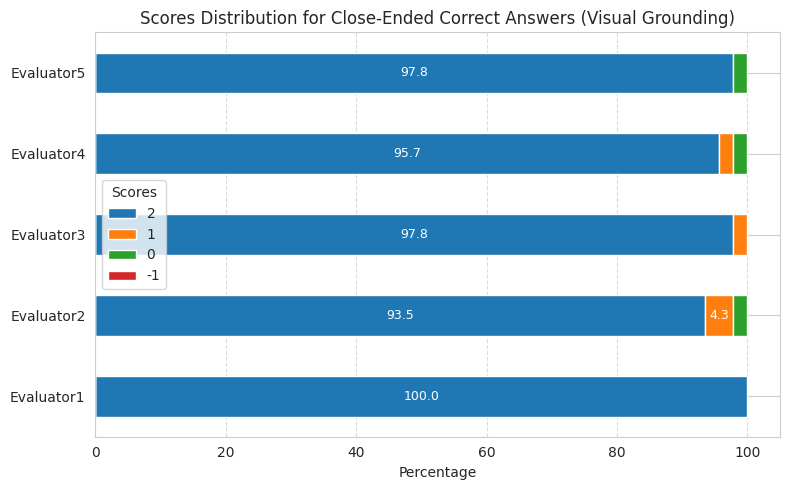

In [48]:
ax = correct_answers_close_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for Close-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers_vis_grounding.png')
plt.show()

In [17]:
wrong_answers_eval_data_combined = wrong_answer_eval_data['evaluator1'] + wrong_answer_eval_data['evaluator2'] + wrong_answer_eval_data['evaluator3'] + wrong_answer_eval_data['evaluator4']
wrong_answers_eval_data_combined

Total  Level 2  Level 1  Level 0  Level -1
Open-Ended Error Proximity     273       51      151       71         0
           Visual Grounding    273       57      120       96         0
MCQ        Error Proximity     736      116      258      359         3
           Visual Grounding    736      124      171      438         3

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Wrong Answers

Open-Ended Error Proximity

In [50]:
wrong_answers_open_ended_error_prox = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator5')])

wrong_answers_open_ended_error_prox['Level 2'] = round((wrong_answers_open_ended_error_prox['Level 2']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level 1'] = round((wrong_answers_open_ended_error_prox['Level 1']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level 0'] = round((wrong_answers_open_ended_error_prox['Level 0']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level -1'] = round((wrong_answers_open_ended_error_prox['Level -1']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox = wrong_answers_open_ended_error_prox.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

wrong_answers_open_ended_error_prox

,2,1,0,-1
Evaluator1,10.53,39.47,50.00,0.0
Evaluator2,60.61,33.33,6.06,0.0
Evaluator3,0.00,72.06,27.94,0.0
Evaluator4,4.76,79.37,15.87,0.0
Evaluator5,6.67,16.00,69.33,8.0


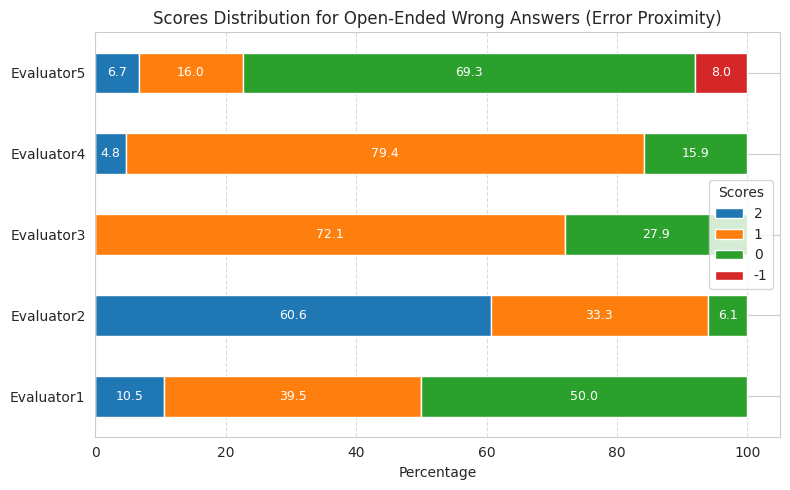

In [51]:
ax = wrong_answers_open_ended_error_prox.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for Open-Ended Wrong Answers (Error Proximity)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers_error_prox.png')
plt.show()

Open-Ended Visual Grounding

In [52]:
wrong_answers_open_ended_vis_grounding = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator5')])

wrong_answers_open_ended_vis_grounding['Level 2'] = round((wrong_answers_open_ended_vis_grounding['Level 2']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level 1'] = round((wrong_answers_open_ended_vis_grounding['Level 1']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level 0'] = round((wrong_answers_open_ended_vis_grounding['Level 0']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level -1'] = round((wrong_answers_open_ended_vis_grounding['Level -1']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding = wrong_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

wrong_answers_open_ended_vis_grounding

,2,1,0,-1
Evaluator1,7.89,42.11,50.00,0.0
Evaluator2,69.70,22.73,7.58,0.0
Evaluator3,7.35,55.88,36.76,0.0
Evaluator4,0.00,55.56,44.44,0.0
Evaluator5,4.00,22.67,65.33,8.0


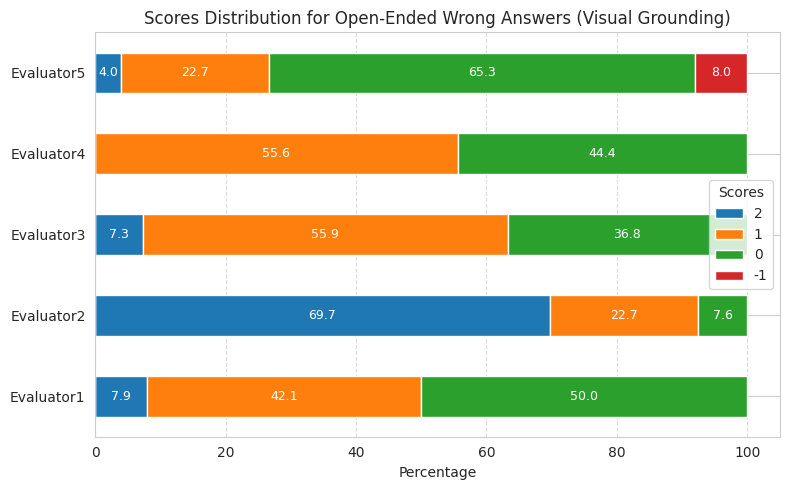

In [53]:
ax = wrong_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for Open-Ended Wrong Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers_vis_grounding.png')
plt.show()

MCQ Error Proximity

In [54]:
wrong_answers_mcq_error_prox = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['MCQ', 'Error Proximity'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['MCQ', 'Error Proximity'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['MCQ', 'Error Proximity'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['MCQ', 'Error Proximity'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['MCQ', 'Error Proximity'].rename('Evaluator5')])

wrong_answers_mcq_error_prox['Level 2'] = round((wrong_answers_mcq_error_prox['Level 2']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level 1'] = round((wrong_answers_mcq_error_prox['Level 1']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level 0'] = round((wrong_answers_mcq_error_prox['Level 0']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level -1'] = round((wrong_answers_mcq_error_prox['Level -1']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox = wrong_answers_mcq_error_prox.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                    'Level 1': '1',
                                                                                                    'Level 0': '0',
                                                                                                    'Level -1': '-1'})

wrong_answers_mcq_error_prox

,2,1,0,-1
Evaluator1,10.33,33.15,54.89,1.63
Evaluator2,50.00,36.41,13.59,0.00
Evaluator3,1.09,36.41,62.50,0.00
Evaluator4,1.63,34.24,64.13,0.00
Evaluator5,5.43,9.78,84.24,0.54


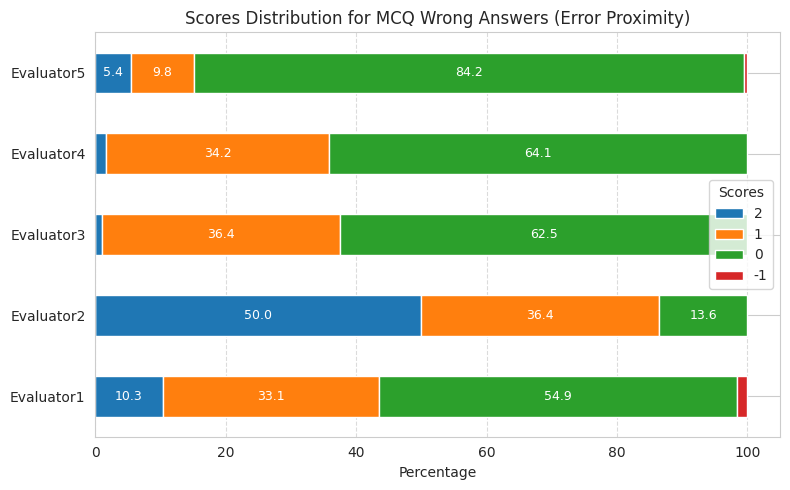

In [55]:
ax = wrong_answers_mcq_error_prox.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for MCQ Wrong Answers (Error Proximity)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers_error_prox.png')
plt.show()

MCQ Visual Grounding

In [56]:
wrong_answers_mcq_vis_grounding = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['MCQ', 'Visual Grounding'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['MCQ', 'Visual Grounding'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['MCQ', 'Visual Grounding'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['MCQ', 'Visual Grounding'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['MCQ', 'Visual Grounding'].rename('Evaluator5')])

wrong_answers_mcq_vis_grounding['Level 2'] = round((wrong_answers_mcq_vis_grounding['Level 2']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level 1'] = round((wrong_answers_mcq_vis_grounding['Level 1']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level 0'] = round((wrong_answers_mcq_vis_grounding['Level 0']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level -1'] = round((wrong_answers_mcq_vis_grounding['Level -1']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding = wrong_answers_mcq_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                    'Level 1': '1',
                                                                                                    'Level 0': '0',
                                                                                                    'Level -1': '-1'})

wrong_answers_mcq_vis_grounding

,2,1,0,-1
Evaluator1,10.33,28.80,59.24,1.63
Evaluator2,53.80,25.00,21.20,0.00
Evaluator3,2.17,21.20,76.63,0.00
Evaluator4,1.09,17.93,80.98,0.00
Evaluator5,3.80,9.78,85.33,1.09


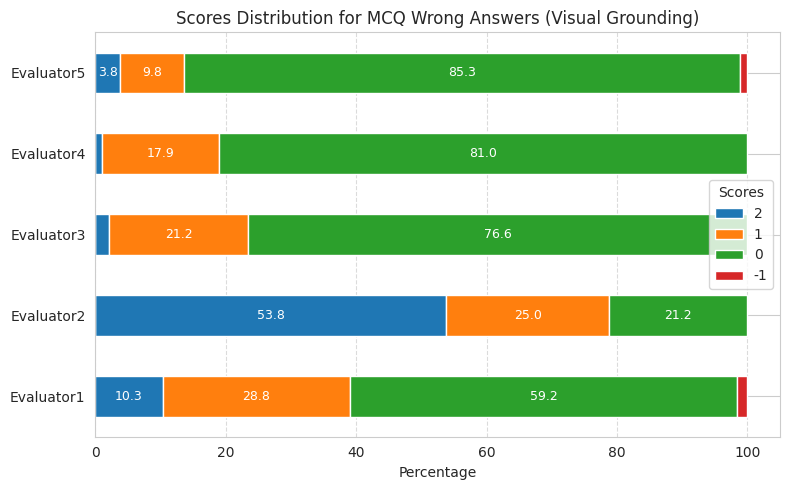

In [57]:
ax = wrong_answers_mcq_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax.set_title('Scores Distribution for MCQ Wrong Answers (Visual Grounding)')
ax.set_xlabel('Percentage')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers_vis_grounding.png')
plt.show()